# List 1

**Introduction to tools for data analysis and classification model building**

In the following tasks you will use the *Adult* dataset available in the `sklearn` library.

In [32]:
from sklearn.datasets import fetch_openml
from sklearn.dummy import DummyClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import matplotlib.pyplot as plt

import pandas as pd
import torch
adult = fetch_openml("adult", version=2, as_frame=True)
df = adult.frame

In this version of the dataset, the target variable is the `class` column.
While completing the tasks, you should use the following libraries: `pandas`, `matplotlib`, `sklearn`, and `torch`.

---

## 1. EDA — pandas

The goal of this section is to become familiar with basic operations on a `DataFrame`.

### Task 1 — Basic information

1. Print the number of rows and columns in the dataset.
2. Print the names of all columns.
3. Check the number of missing values in each column.
4. Display descriptive statistics for numerical columns using the appropriate `pandas` method.

In [33]:
n_rows, n_cols = df.shape

print(f'Number of columns: {n_cols}')
print(f'Number of rows: {n_rows}')

Number of columns: 15
Number of rows: 48842


In [34]:
col_names = df.columns.to_list()
print(col_names)

['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'class']


In [35]:
df_nan = df.isna()

for name in col_names:
    n_nan = df_nan[name].sum(axis=0)
    print(f'{name}: {n_nan}')

age: 0
workclass: 2799
fnlwgt: 0
education: 0
education-num: 0
marital-status: 0
occupation: 2809
relationship: 0
race: 0
sex: 0
capital-gain: 0
capital-loss: 0
hours-per-week: 0
native-country: 857
class: 0


In [36]:
df.describe(include='number')

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


### Task 2 — Category counts

1. Compute the number of observations in each category of the `education` variable.
2. Sort the result in descending order by count.
3. Print the five most frequent categories.

In [37]:
cat_counts: pd.Series = df.groupby('education').size()
cat_counts.sort_values(ascending=False).head(5)

education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
dtype: int64

### Task 3 — Grouping and aggregation

For each category of the `education` variable, compute:

* the mean value of `hours-per-week`,
* the mean value of `capital-gain`,
* the percentage of observations belonging to the `>50K` class (based on the `class` column).

Use the `groupby()` and `agg()` methods.

In [38]:
cat_df = df.groupby('education').agg(
    avg_hours_per_week=("hours-per-week", "mean"),
    avg_capital_gain=("capital-gain", "mean"),
    perc_class=("class", lambda x: (x == ">50K").mean())
)

print(cat_df)

              avg_hours_per_week  avg_capital_gain  perc_class
education                                                     
10th                   36.986321        323.049676    0.062635
11th                   33.952539        203.739514    0.050773
12th                   35.374429        208.579909    0.073059
1st-4th                38.761134        123.591093    0.032389
5th-6th                38.923379        360.365422    0.053045
7th-8th                39.003141        242.626178    0.064921
9th                    38.359788        313.398148    0.054233
Assoc-acdm             40.809494        636.951905    0.257964
Assoc-voc              41.658418        778.602135    0.253275
Bachelors              42.482492       1762.564984    0.412835
Doctorate              46.582492       5727.769360    0.725589
HS-grad                40.640775        573.314179    0.158578
Masters                43.575837       2583.605947    0.549116
Preschool              36.566265        732.000000    0

### Task 4 — Filtering data

1. Select observations for which `capital-gain > 0`.
2. Compute the mean `hours-per-week` for this group.
3. Compute the mean `hours-per-week` for observations with `capital-gain == 0`.

In [39]:
capgain_df = df[df["capital-gain"] > 0].agg(
    avg_hours_per_week=("hours-per-week", "mean")
)

print(capgain_df)

capgain_df = df[df["capital-gain"] == 0].agg(
    avg_hours_per_week=("hours-per-week", "mean")
)

print(capgain_df)

                    hours-per-week
avg_hours_per_week       43.526146
                    hours-per-week
avg_hours_per_week       40.142879


### Task 5 — Creating a new column

1. Create a new column called `hours_bucket` by dividing `hours-per-week` into intervals of 10 hours using `pd.cut`.
2. Compute the number of observations in each interval.
3. Create a pivot table in which:

   * the index is `hours_bucket`,
   * the columns correspond to `class`,
   * the values represent the number of observations.

In [40]:
max_h = df["hours-per-week"].max()

bins = range(0, max_h + 10, 10)

df["hours_bucket"] = pd.cut(df["hours-per-week"], bins=bins)

df.groupby("hours_bucket").size()

pivot_tab = pd.pivot_table(df, index="hours_bucket", columns="class", aggfunc="size")
print(pivot_tab)

class         <=50K  >50K
hours_bucket             
(0, 10]        1020   105
(10, 20]       3132   196
(20, 30]       3173   225
(30, 40]      21220  5419
(40, 50]       5398  3519
(50, 60]       2135  1624
(60, 70]        570   332
(70, 80]        289   167
(80, 90]         95    52
(90, 100]       123    48


## 2. Visualization — matplotlib

Each plot must include a title, axis labels, and a legend (if applicable).

---

### Plot 1 — Histogram

Create a histogram of the `hours-per-week` variable.
Choose the number of bins in a reasonable way.

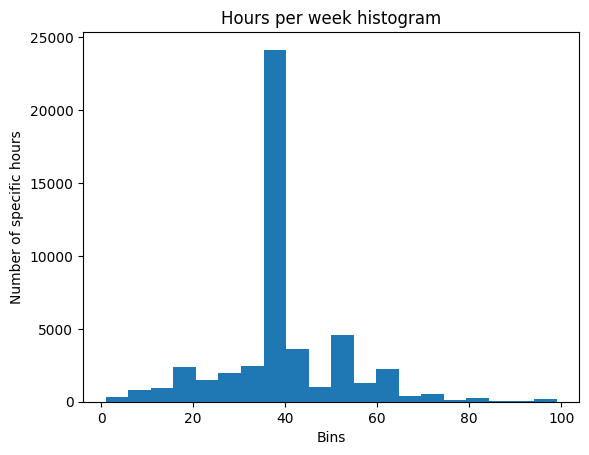

In [41]:
plt.figure(0)
plt.title("Hours per week histogram")
plt.xlabel("Bins")
plt.ylabel("Number of specific hours")
plt.hist(df["hours-per-week"], bins=20)
plt.show()

### Plot 2 — Histogram comparison

On a single figure, plot two histograms of `hours-per-week`:

* one for the `<=50K` class,
* one for the `>50K` class.

The histograms should be semi-transparent (set the `alpha` parameter).

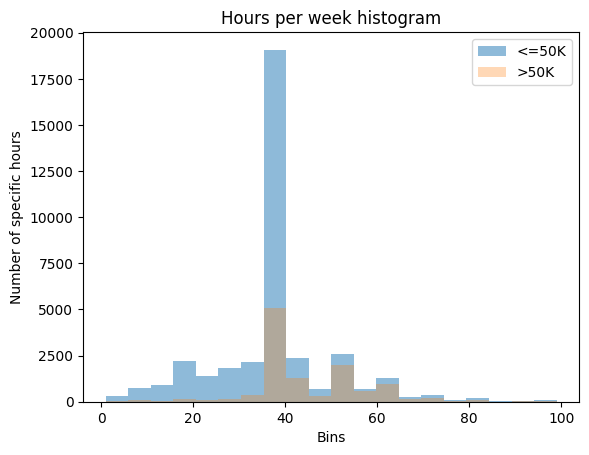

In [42]:
plt.figure(1)
plt.title("Hours per week histogram")
plt.xlabel("Bins")
plt.ylabel("Number of specific hours")
plt.hist(df[df["class"] == "<=50K"]["hours-per-week"], bins=20, alpha=0.5, label="<=50K")
plt.hist(df[df["class"] == ">50K"]["hours-per-week"], bins=20, alpha=0.3, label=">50K")

plt.legend()
plt.show()

### Plot 3 — Bar chart

Create a bar chart showing the number of observations for each category of the `education` variable.

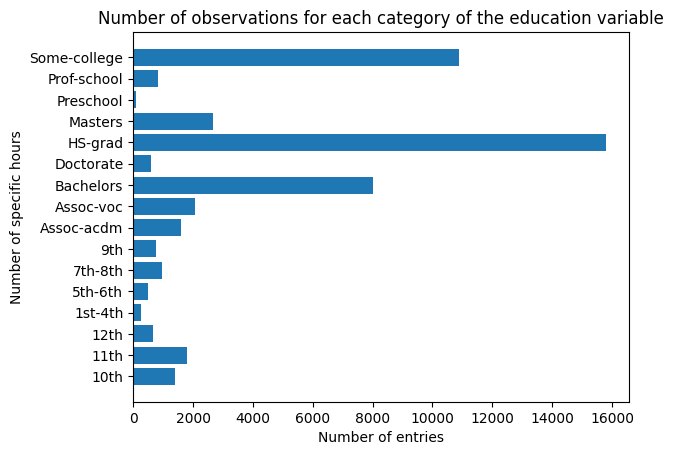

In [43]:
plt.figure(2)
plt.title("Number of observations for each category of the education variable")
plt.xlabel("Number of entries")
plt.ylabel("Number of specific hours")
plt.barh(cat_counts.index, cat_counts.values)
plt.show()

### Plot 4 — Scatter plot

Create a scatter plot where:

* the X-axis represents `capital-gain`,
* the Y-axis represents `hours-per-week`.

Set `alpha < 0.3`.

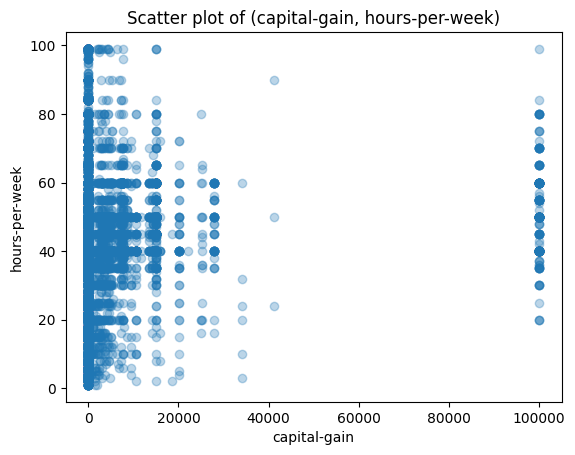

In [44]:
plt.figure(3)
plt.title("Scatter plot of (capital-gain, hours-per-week)")
plt.xlabel("capital-gain")
plt.ylabel("hours-per-week")
plt.scatter(df['capital-gain'], df['hours-per-week'], alpha=0.3)
plt.show()

### Plot 5 — Logarithmic scale

Create a histogram of `capital-gain`.
Set the X-axis to a logarithmic scale.

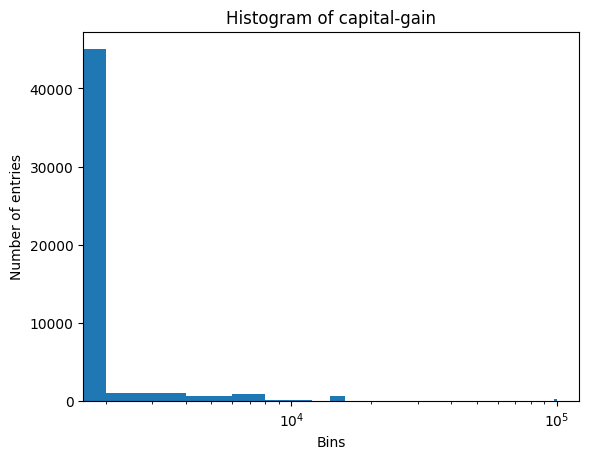

In [45]:
plt.figure(4)
plt.title("Histogram of capital-gain")
plt.xlabel("Bins")
plt.ylabel("Number of entries")
plt.hist(df['capital-gain'], bins=50)
plt.xscale('log')
plt.show()

## 3. Data splitting — sklearn

Before splitting the data, separate:

* the feature matrix `X` (all columns except `class`),
* the target vector `y` (the `class` column).

In [46]:
df_x = df[list(set(col_names) - set(["class"]))]
df_y = df['class']

df_x.head(5)

,education-num,fnlwgt,native-country,race,capital-gain,marital-status,workclass,hours-per-week,capital-loss,education,age,occupation,relationship,sex
0,7,226802,United-States,Black,0,Never-married,Private,40,0,11th,25,Machine-op-inspct,Own-child,Male
1,9,89814,United-States,White,0,Married-civ-spouse,Private,50,0,HS-grad,38,Farming-fishing,Husband,Male
2,12,336951,United-States,White,0,Married-civ-spouse,Local-gov,40,0,Assoc-acdm,28,Protective-serv,Husband,Male
3,10,160323,United-States,Black,7688,Married-civ-spouse,Private,40,0,Some-college,44,Machine-op-inspct,Husband,Male
4,10,103497,United-States,White,0,Never-married,NaN,30,0,Some-college,18,NaN,Own-child,Female


In [47]:
df_y.head(5)

0    <=50K
1    <=50K
2     >50K
3     >50K
4    <=50K
Name: class, dtype: category
Categories (2, str): ['<=50K', '>50K']

### Task 1 — Train/validation/test split

1. Split the data into:

   * training set (60%),
   * validation set (20%),
   * test set (20%).

2. Use `train_test_split` with the `stratify=y` parameter to preserve class proportions.

3. Print the size of each split.

4. Print the class proportions in each split.

In [48]:
X_train, X_temp, y_train, y_temp = train_test_split(
    df_x, df_y, test_size=0.4, stratify=df_y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp
)

print(f'Train: {X_train.shape[0]}')
print(f'Val: {X_val.shape[0]}')
print(f'Test: {X_test.shape[0]}')

print(f'Train: {y_train.value_counts(normalize=True)}')
print(f'Val: {y_val.value_counts(normalize=True)}')
print(f'Test: {y_test.value_counts(normalize=True)}')

Train: 29305
Val: 9768
Test: 9769
Train: class
<=50K    0.760723
>50K     0.239277
Name: proportion, dtype: float64
Val: class
<=50K    0.760749
>50K     0.239251
Name: proportion, dtype: float64
Test: class
<=50K    0.760672
>50K     0.239328
Name: proportion, dtype: float64


### Task 2 — Baseline model

The baseline model is a classifier that does not use input features and always predicts the majority class from the training set.

1. Determine the majority class in the training set.
2. Build a classifier that predicts this class for all test observations.
3. Compute the following metrics on the test set:

   * Accuracy,
   * Precision,
   * Recall,
   * F1.

You may implement this manually or use `DummyClassifier(strategy="most_frequent")`.

In [49]:
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf .fit(X_train, y_train)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

y_pred = dummy_clf.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, y_pred)}')
print(f"Precision: {precision_score(y_test, y_pred, pos_label='>50K', zero_division=0)}")
print(f"Recall: {recall_score(y_test, y_pred, pos_label='>50K', zero_division=0)}")
print(f"F1: {f1_score(y_test, y_pred, pos_label='>50K', zero_division=0)}")

Accuracy: 0.7606715119254785
Precision: 0.0
Recall: 0.0
F1: 0.0


## 4. Pipeline — sklearn

### Task 1 — Preprocessing

1. Split the columns into numerical and categorical features.

2. Build a `ColumnTransformer` where:

   * numerical columns are processed with:

     * `SimpleImputer(strategy="median")`,
     * `StandardScaler`,
   * categorical columns are processed with:

     * `SimpleImputer(strategy="most_frequent")`,
     * `OneHotEncoder(handle_unknown="ignore")`.

3. Fit the preprocessing pipeline on the training set and check the shape of the transformed feature matrix.

In [50]:
num_cols = X_train.select_dtypes(include=['number']).columns
cat_cols = X_train.select_dtypes(include=['category']).columns

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("scaler", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

X_train_preprocessed = preprocessor.fit_transform(X_train)

print(X_train_preprocessed.shape)

(29305, 104)


### Task 2 — Logistic regression

1. Build a `Pipeline` consisting of:

   * preprocessing,
   * `LogisticRegression(max_iter=1000)`.

2. Train the model on the training set.

3. Compute the following metrics on the validation set:

   * Accuracy,
   * F1,

In [51]:
log_reg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

log_reg_pipeline.fit(X_train, y_train)

y_pred = log_reg_pipeline.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, y_pred)}')
print(f"F1: {f1_score(y_test, y_pred, pos_label='>50K')}")

Accuracy: 0.8407206469444161
F1: 0.6352555086732302


## 5. GridSearch

### Task — Hyperparameter tuning for logistic regression

1. Define the parameter grid:

   * `C`: [0.01, 0.1, 1, 10].

2. Use `GridSearchCV` with:

   * `scoring="f1"`,
   * `cv=5`.

3. Fit the model on the training set.

4. Print the best parameters (`best_params_`) and the best cross-validation score (`best_score_`).

In [52]:
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10]
}

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score

custom_f1 = make_scorer(f1_score, pos_label='>50K')
clf = GridSearchCV(log_reg_pipeline, param_grid, scoring=custom_f1, cv=5)

clf.fit(X_train, y_train)
print(f"best params: {clf.best_params_}")
print(f"best score: {clf.best_score_:.4f}")

best params: {'classifier__C': 1}
best score: 0.6614


## 6. MLP — PyTorch

In this section, use the data after preprocessing (the same transformations as in `sklearn`).

1. Fit the preprocessing pipeline on the training set.
2. Transform the training, validation, and test sets.
3. Convert the resulting matrices to `float32` tensors.
4. Encode the labels as 0 and 1.

---

### Task 1 — Network architecture

Build an MLP with the following structure:

* Input layer: number of neurons equal to the number of features after preprocessing.
* Hidden layer 1: `Linear(in_features, 128)` → `ReLU` → `Dropout(p=0.3)`.
* Hidden layer 2: `Linear(128, 64)` → `ReLU` → `Dropout(p=0.3)`.
* Hidden layer 3: `Linear(64, 32)` → `ReLU` → `Dropout(p=0.3)`.
* Output layer: `Linear(32, 1)`.

Do not apply a sigmoid activation inside the model.
Use `BCEWithLogitsLoss` as the loss function.

In [53]:
preprocessor.fit(X_train)
X_train_final = preprocessor.transform(X_train)
X_val_final = preprocessor.transform(X_val)
X_test_final = preprocessor.transform(X_test)

if hasattr(X_train_final, "toarray"):
    X_train_final = X_train_final.toarray()
    X_val_final = X_val_final.toarray()
    X_test_final = X_test_final.toarray()

X_train_t = torch.tensor(X_train_final, dtype=torch.float32)
X_val_t = torch.tensor(X_val_final, dtype=torch.float32)
X_test_t = torch.tensor(X_test_final, dtype=torch.float32)

label_mapping = {'<=50K': 0, '>50K': 1}

y_train_t = torch.tensor(y_train.map(label_mapping).values, dtype=torch.float32).reshape(-1, 1)
y_val_t = torch.tensor(y_val.map(label_mapping).values, dtype=torch.float32).reshape(-1, 1)
y_test_t = torch.tensor(y_test.map(label_mapping).values, dtype=torch.float32).reshape(-1, 1)

import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.architecture = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(p=0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p=0.3),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(p=0.3),

            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        return self.architecture(x)

### Task 2 — Training

1. Use the `Adam` optimizer.

2. Apply a `StepLR` scheduler with `step_size=5` and `gamma=0.5`.

3. Implement early stopping with `patience=5`, monitoring the validation loss.

4. During each epoch, record:

   * training loss,
   * validation loss,
   * validation accuracy.

5. After training, plot training loss and validation loss as a function of epoch number.

Early stopping triggered at epoch 10


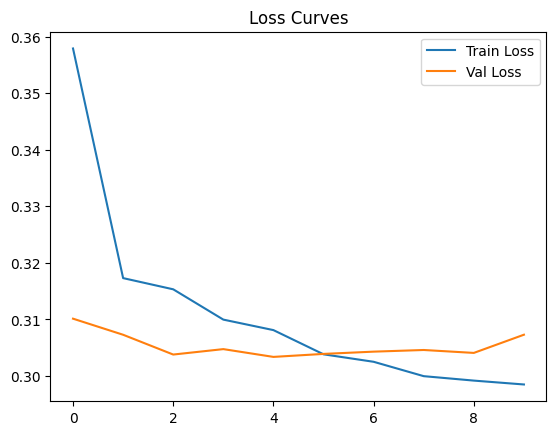

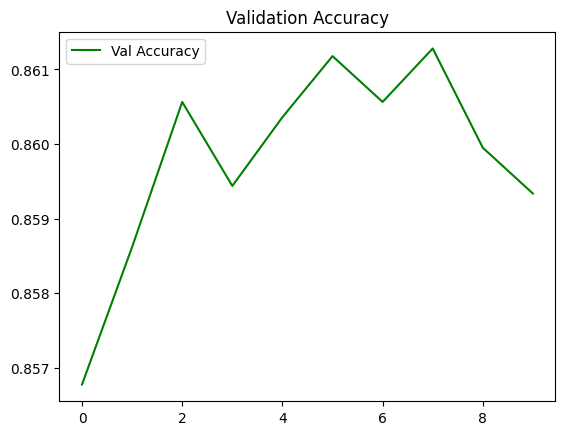

In [54]:
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

BATCH_SIZE = 64

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = TensorDataset(X_val_t, y_val_t)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

input_dim = X_train_t.shape[1]
mlp = MLP(input_dim)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(mlp.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

train_losses, val_losses, val_accuracies = [], [], []
best_val_loss = float('inf')
current_patience = 0
PATIENCE = 5
EPOCHS = 100

for epoch in range(EPOCHS):
    mlp.train()
    running_train_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = mlp(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * batch_X.size(0)
    
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    scheduler.step()

    mlp.eval()
    running_val_loss = 0.0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            outputs = mlp(batch_X)
            loss = criterion(outputs, batch_y)
            running_val_loss += loss.item() * batch_X.size(0)
            
            # For accuracy calculation
            preds = (torch.sigmoid(outputs) > 0.5).float()
            all_preds.extend(preds.numpy())
            all_targets.extend(batch_y.numpy())

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_acc = accuracy_score(all_targets, all_preds)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        current_patience = 0
    else:
        current_patience += 1

    if current_patience >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

plt.figure()
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss Curves')
plt.legend()
plt.show()

plt.figure()
plt.plot(val_accuracies, label='Val Accuracy', color='green')
plt.title('Validation Accuracy')
plt.legend()
plt.show()

### Task 3 — Evaluation

On the test set, compute:

* Accuracy,
* F1.

In [55]:
mlp.eval()
with torch.no_grad():
    y_pred_mlp = mlp(X_test_t)
    predictions_mlp = (y_pred_mlp > 0.0).float().numpy().flatten()

y_test_np = y_test_t.numpy().flatten()

accuracy_mlp = accuracy_score(y_test_np, predictions_mlp)
f1_mlp = f1_score(y_test_np, predictions_mlp, pos_label=1)

print(f'Accuracy score: {accuracy_mlp}')
print(f'F1 score: {f1_mlp}')

Accuracy score: 0.8482956290306071
F1 score: 0.6360510805500982


## 7. Error analysis

1. Compute predicted probabilities for the positive class on the test set.
2. Identify:

   * 50 false positive cases with the highest predicted probability,
   * 50 false negative cases with the highest predicted probability.

In [56]:
y_pred_mlp = y_pred_mlp.numpy().flatten()
error_df = X_test.copy()
error_df['probs'] = y_pred_mlp
error_df['pred_class'] = predictions_mlp
error_df['true_class'] = y_test_np

error_df.head(5)

,education-num,fnlwgt,native-country,race,capital-gain,marital-status,workclass,hours-per-week,capital-loss,education,age,occupation,relationship,sex,probs,pred_class,true_class
30074,10,386643,United-States,White,0,Never-married,Private,40,0,Some-college,20,Other-service,Own-child,Female,-8.027302,0.0,0.0
8034,10,157403,United-States,White,0,Never-married,Private,38,0,Some-college,40,Craft-repair,Unmarried,Male,-2.904060,0.0,0.0
7924,9,112858,United-States,White,0,Never-married,NaN,2,0,HS-grad,20,NaN,Own-child,Male,-13.247228,0.0,0.0
14331,13,52263,United-States,White,0,Never-married,Private,40,0,Bachelors,38,Tech-support,Not-in-family,Male,-2.648274,0.0,0.0
1532,3,445758,Mexico,White,0,Never-married,Private,40,0,5th-6th,23,Handlers-cleaners,Unmarried,Male,-12.483277,0.0,0.0


In [57]:
fp_df = error_df[(error_df['pred_class'] == 1) & (error_df['true_class'] == 0)]
fn_df = error_df[(error_df['pred_class'] == 0) & (error_df['true_class'] == 1)]

In [58]:
fp_df.nlargest(50, 'probs').head(10)

,education-num,fnlwgt,native-country,race,capital-gain,marital-status,workclass,hours-per-week,capital-loss,education,age,occupation,relationship,sex,probs,pred_class,true_class
31657,9,145574,United-States,White,34095,Divorced,Self-emp-not-inc,60,0,HS-grad,55,Exec-managerial,Not-in-family,Male,13.862517,1.0,0.0
23467,9,188815,United-States,White,34095,Never-married,Private,20,0,HS-grad,19,Other-service,Own-child,Female,3.395663,1.0,0.0
26770,14,192386,United-States,White,5013,Married-civ-spouse,Federal-gov,40,0,Masters,52,Exec-managerial,Husband,Male,2.866596,1.0,0.0
6706,14,227113,United-States,White,0,Married-civ-spouse,Private,40,2457,Masters,67,Prof-specialty,Husband,Male,2.834116,1.0,0.0
33761,16,180079,United-States,White,4064,Married-civ-spouse,Local-gov,40,0,Doctorate,61,Exec-managerial,Husband,Male,2.792443,1.0,0.0
35086,13,182191,Canada,White,4064,Married-civ-spouse,NaN,30,0,Bachelors,31,NaN,Wife,Female,2.738681,1.0,0.0
30071,13,169982,United-States,White,0,Married-civ-spouse,Private,50,2002,Bachelors,59,Exec-managerial,Husband,Male,2.727522,1.0,0.0
1158,16,107503,United-States,White,5013,Married-civ-spouse,State-gov,60,0,Doctorate,44,Prof-specialty,Husband,Male,2.716635,1.0,0.0
3056,13,121012,United-States,White,5013,Married-civ-spouse,Private,45,0,Bachelors,44,Exec-managerial,Husband,Male,2.573678,1.0,0.0
7400,13,234738,United-States,White,5013,Married-civ-spouse,Self-emp-inc,50,0,Bachelors,62,Exec-managerial,Husband,Male,2.318643,1.0,0.0


In [59]:
fn_df.nlargest(50, 'probs').head(10)

,education-num,fnlwgt,native-country,race,capital-gain,marital-status,workclass,hours-per-week,capital-loss,education,age,occupation,relationship,sex,probs,pred_class,true_class
15584,9,196344,United-States,White,0,Married-civ-spouse,Private,45,1887,HS-grad,40,Craft-repair,Husband,Male,-0.004374,0.0,1.0
42270,10,219886,United-States,White,0,Married-civ-spouse,Private,40,0,Some-college,61,Tech-support,Wife,Female,-0.007806,0.0,1.0
30751,10,409200,United-States,White,0,Married-civ-spouse,Local-gov,40,0,Some-college,38,Tech-support,Husband,Male,-0.009439,0.0,1.0
436,13,183977,United-States,White,0,Married-civ-spouse,Private,55,0,Bachelors,32,Craft-repair,Husband,Male,-0.010221,0.0,1.0
40774,11,400004,United-States,White,0,Married-civ-spouse,Private,40,0,Assoc-voc,52,Exec-managerial,Husband,Male,-0.013428,0.0,1.0
37596,13,253814,United-States,White,0,Married-civ-spouse,Private,40,0,Bachelors,27,Tech-support,Wife,Female,-0.016202,0.0,1.0
25746,9,303637,United-States,White,0,Married-civ-spouse,Private,49,0,HS-grad,47,Exec-managerial,Husband,Male,-0.018321,0.0,1.0
37210,10,237671,United-States,White,0,Married-civ-spouse,Private,40,0,Some-college,40,Tech-support,Wife,Female,-0.023705,0.0,1.0
31900,13,182566,United-States,Black,0,Married-civ-spouse,Private,40,0,Bachelors,48,Sales,Husband,Male,-0.025627,0.0,1.0
5051,10,56962,United-States,White,0,Married-civ-spouse,Private,43,0,Some-college,39,Exec-managerial,Wife,Female,-0.030870,0.0,1.0


## 8. Final report

In the final report, answer the following questions:

1. Which model achieved the highest F1 score?
2. Do the learning curves indicate a stable training process?
3. Did overfitting occur in the MLP model (compare training and validation loss)?

1. The highest F1 score was achieved by the MLP model.
2. Yes the curves indicate stable training process.
3. Yes the MLP model did not learn to generalize, the validation loss stayed constant.